# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Vaibhav Kiran Ghaisas"
student_id = "25415629"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [7]:
# <Student to fill this section>
business_use_case_description = """
Embedding AI services, by making Machine Learning models available as a service, in the weather forecast and API services offered by 'Open Meteo'.


1. To build machine learning model leveraging the historal weather data to predict whether or not it will rain, 7 days in advance. Probable intended audience are Farmers, Emergency services personnel, and so on.
2. To build machine learning model leveraging meteorological features from the historal weather data to predict the cummulated volume of precipitation with next 3 days from the present day. Intended end users would be people to plan their transport in advance; would be emergency services personnel to issue flood alerts and so on.
"""

In [8]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [9]:
# <Student to fill this section>
business_objectives = """
Accurate predictions will enable people to plan their commute well in advance.
Accurate predictions followed up with the weather warnings can help avoid undesirable emergency situations like loss of life due to excessive precipitaion and eventually flooding.
Accurate predictions will enable farmers plan their activities in advance and be ready for the weather conditions.

Inaccurate predictions can lead to emergency services issuing incorrect weather warnings or advisories which will impact people negatively. For example if the advisory was issued for flooding in the area within the next 3 days and people were to vacate the area, it will cause unnecessary movement if there was no flooding as forecasted.
Inaccurate predictions can lead to travellers planning over safely and avoiding the option to a more quicker and easily available source of transportation, costing them their time and money.
Inaccurate predictions can lead to farmers planning their activities over cautiously and end up with lesser harvest than expected otherwise.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [11]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Accurate predictions will enable people to plan their commute well in advance. Accurate predictions followed up with the weather warnings can help avoid undesirable emergency situations like loss of life due to excessive precipitaion and eventually flooding. Accurate predictions will enable farmers plan their activities in advance and be ready for the weather conditions. Inaccurate predictions can lead to emergency services issuing incorrect weather warnings or advisories which will impact people negatively. For example if the advisory was issued for flooding in the area within the next 3 days and people were to vacate the area, it will cause unnecessary movement if there was no flooding as forecasted. Inaccurate predictions can lead to travellers planning over safely and avoiding the option to a more quicker and easily available source of transportation, costing them their time and money. Inaccurate predictions can lead to farmers planning their activities over cautiously and end up with lesser harvest than expected otherwise.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [13]:
# <Student to fill this section>
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": -33.8678,
	"longitude": 151.2073,
	"start_date": "2000-01-01",
	"end_date": "2024-12-31",
	"daily": ["precipitation_sum", "weather_code", "temperature_2m_max", 
           "temperature_2m_min", "cloud_cover_mean", "cloud_cover_max", 
           "cloud_cover_min", "dew_point_2m_mean", "dew_point_2m_max", 
           "dew_point_2m_min", "relative_humidity_2m_mean", "relative_humidity_2m_max", 
           "relative_humidity_2m_min", "pressure_msl_mean", "pressure_msl_max", 
           "pressure_msl_min", "wind_speed_10m_max", "wind_speed_10m_mean", 
           "wind_speed_10m_min", "winddirection_10m_dominant", "temperature_2m_mean"],
}
responses = openmeteo.weather_api(url, params=params)

# Process the response for the selected location
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

Coordinates: -33.84885787963867°N 151.1955108642578°E
Elevation: 51.0 m asl
Timezone difference to GMT+0: 0s


In [14]:
# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_precipitation_sum = daily.Variables(0).ValuesAsNumpy()
daily_weather_code = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(2).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(3).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(4).ValuesAsNumpy()
daily_cloud_cover_max = daily.Variables(5).ValuesAsNumpy()
daily_cloud_cover_min = daily.Variables(6).ValuesAsNumpy()
daily_dew_point_2m_mean = daily.Variables(7).ValuesAsNumpy()
daily_dew_point_2m_max = daily.Variables(8).ValuesAsNumpy()
daily_dew_point_2m_min = daily.Variables(9).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(10).ValuesAsNumpy()
daily_relative_humidity_2m_max = daily.Variables(11).ValuesAsNumpy()
daily_relative_humidity_2m_min = daily.Variables(12).ValuesAsNumpy()
daily_pressure_msl_mean = daily.Variables(13).ValuesAsNumpy()
daily_pressure_msl_max = daily.Variables(14).ValuesAsNumpy()
daily_pressure_msl_min = daily.Variables(15).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(16).ValuesAsNumpy()
daily_wind_speed_10m_mean = daily.Variables(17).ValuesAsNumpy()
daily_wind_speed_10m_min = daily.Variables(18).ValuesAsNumpy()
daily_winddirection_10m_dominant = daily.Variables(19).ValuesAsNumpy()
daily_temperature_2m_mean = daily.Variables(20).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["weather_code"] = daily_weather_code
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean
daily_data["cloud_cover_max"] = daily_cloud_cover_max
daily_data["cloud_cover_min"] = daily_cloud_cover_min
daily_data["dew_point_2m_mean"] = daily_dew_point_2m_mean
daily_data["dew_point_2m_max"] = daily_dew_point_2m_max
daily_data["dew_point_2m_min"] = daily_dew_point_2m_min
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["relative_humidity_2m_max"] = daily_relative_humidity_2m_max
daily_data["relative_humidity_2m_min"] = daily_relative_humidity_2m_min
daily_data["pressure_msl_mean"] = daily_pressure_msl_mean
daily_data["pressure_msl_max"] = daily_pressure_msl_max
daily_data["pressure_msl_min"] = daily_pressure_msl_min
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean
daily_data["wind_speed_10m_min"] = daily_wind_speed_10m_min
daily_data["winddirection_10m_dominant"] = daily_winddirection_10m_dominant
daily_data["temperature_2m_mean"] = daily_temperature_2m_mean

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nFirst 5 rows of daily_dataframe: \n", daily_dataframe.head())


First 5 rows of daily_dataframe: 
                        date  precipitation_sum  weather_code  \
0 2000-01-01 00:00:00+00:00                1.2          51.0   
1 2000-01-02 00:00:00+00:00                1.7          51.0   
2 2000-01-03 00:00:00+00:00                0.0           3.0   
3 2000-01-04 00:00:00+00:00                2.2          61.0   
4 2000-01-05 00:00:00+00:00                0.0           3.0   

   temperature_2m_max  temperature_2m_min  cloud_cover_mean  cloud_cover_max  \
0           20.370499           15.820500         92.416664            100.0   
1           20.520500           15.170500         51.916668             95.0   
2           24.520500           18.620499         59.500000            100.0   
3           28.270500           16.470501         18.208334             94.0   
4           23.070499           15.820500         45.208332             97.0   

   cloud_cover_min  dew_point_2m_mean  dew_point_2m_max  ...  \
0             81.0          12.774

In [15]:
print("Columns in daily_dataframe:\n", daily_dataframe.columns)
print("\nShape of daily_dataframe: ", daily_dataframe.shape)
print("\nData types of columns in daily_dataframe:\n", daily_dataframe.dtypes)

Columns in daily_dataframe:
 Index(['date', 'precipitation_sum', 'weather_code', 'temperature_2m_max',
       'temperature_2m_min', 'cloud_cover_mean', 'cloud_cover_max',
       'cloud_cover_min', 'dew_point_2m_mean', 'dew_point_2m_max',
       'dew_point_2m_min', 'relative_humidity_2m_mean',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'pressure_msl_mean', 'pressure_msl_max', 'pressure_msl_min',
       'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_speed_10m_min',
       'winddirection_10m_dominant', 'temperature_2m_mean'],
      dtype='object')

Shape of daily_dataframe:  (9132, 22)

Data types of columns in daily_dataframe:
 date                          datetime64[ns, UTC]
precipitation_sum                         float32
weather_code                              float32
temperature_2m_max                        float32
temperature_2m_min                        float32
cloud_cover_mean                          float32
cloud_cover_max                    

### C.2 Define Target variable

In [16]:
# <Student to fill this section>
target = daily_dataframe['weather_code']

In [17]:
# <Student to fill this section>
target_definition_explanations = """
There are 2 target variables for 2 prediction problems. For predicting whether or not it will rain, the target variable is "weather_code" that will tell us if it will rain. For predicting the cummulated volume of precipitation within next 3 days, the target variable is "precipitation_sum" that represents the total precipitation per day. Once we have our predictions for the next three days, the solution would be to get the cummulative volume(sum).
"""

In [18]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [19]:
# Creating a binary target variable column from weather_code (1: Rain, 0: No Rain)

# Define rain-related weather codes (from OpenMeteo Weather Forecast documentation)
rain_codes = {
    51, 53, 55,        # Drizzle (light, moderate, dense)
    56, 57,            # Freezing drizzle
    61, 63, 65,        # Rain (slight, moderate, heavy)
    66, 67,            # Freezing rain (light, heavy)
    80, 81, 82,        # Rain showers (slight, moderate, violent)
    95, 96, 99         # Thunderstorms (with/without hail)
}

# Create binary rain target
daily_dataframe["rain_label"] = daily_dataframe["weather_code"].isin(rain_codes).astype(int)

# Check the target variable
print(daily_dataframe[["date", "weather_code", "rain_label"]].head(20))

                        date  weather_code  rain_label
0  2000-01-01 00:00:00+00:00          51.0           1
1  2000-01-02 00:00:00+00:00          51.0           1
2  2000-01-03 00:00:00+00:00           3.0           0
3  2000-01-04 00:00:00+00:00          61.0           1
4  2000-01-05 00:00:00+00:00           3.0           0
5  2000-01-06 00:00:00+00:00           3.0           0
6  2000-01-07 00:00:00+00:00          51.0           1
7  2000-01-08 00:00:00+00:00          51.0           1
8  2000-01-09 00:00:00+00:00          51.0           1
9  2000-01-10 00:00:00+00:00          51.0           1
10 2000-01-11 00:00:00+00:00          53.0           1
11 2000-01-12 00:00:00+00:00          53.0           1
12 2000-01-13 00:00:00+00:00          51.0           1
13 2000-01-14 00:00:00+00:00          51.0           1
14 2000-01-15 00:00:00+00:00          51.0           1
15 2000-01-16 00:00:00+00:00          63.0           1
16 2000-01-17 00:00:00+00:00          53.0           1
17 2000-01

### C.4 Explore Target variable

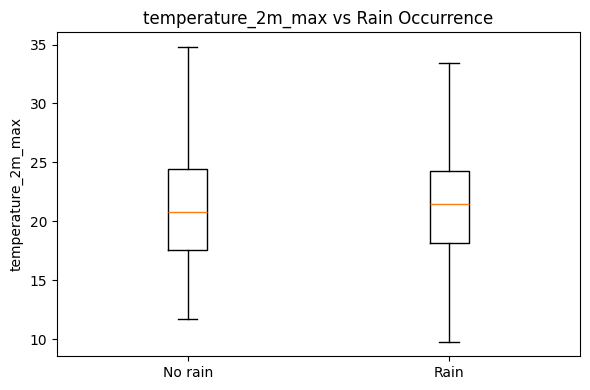

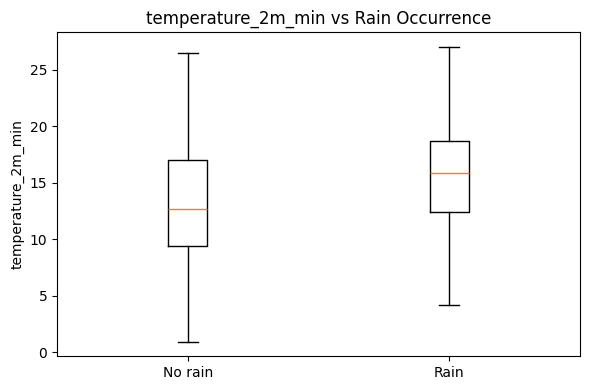

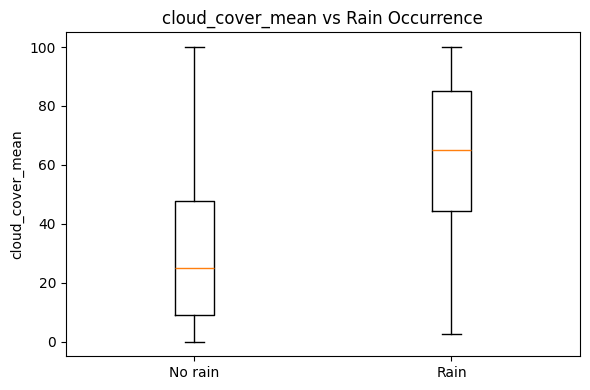

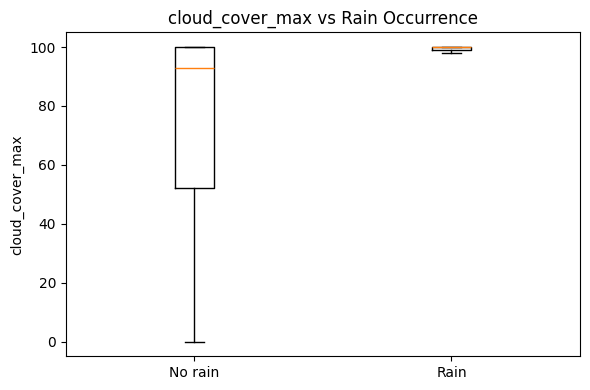

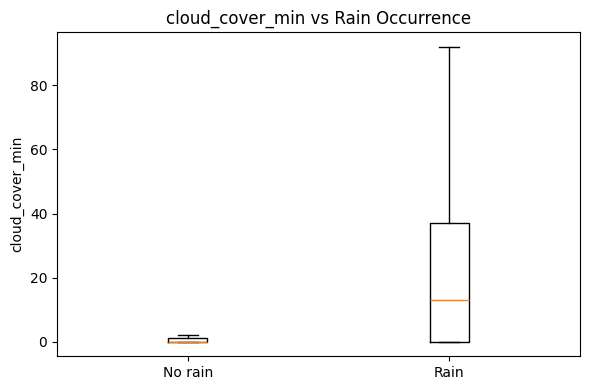

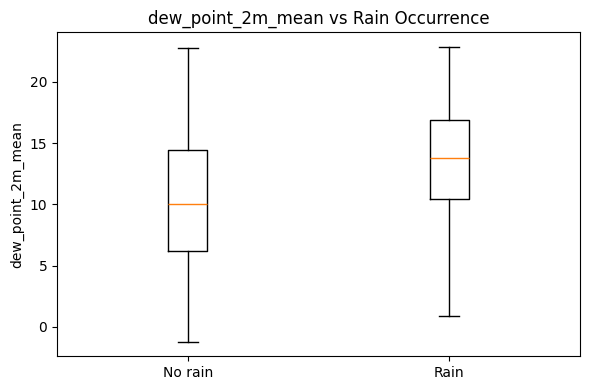

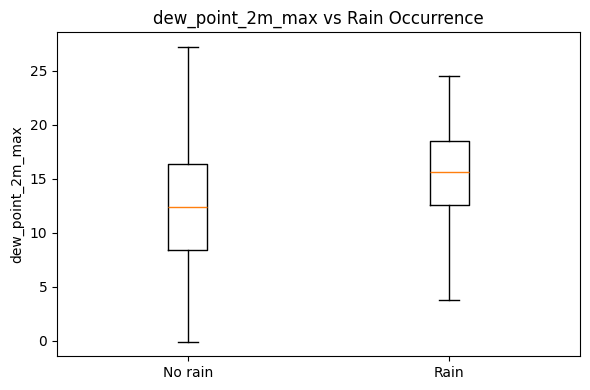

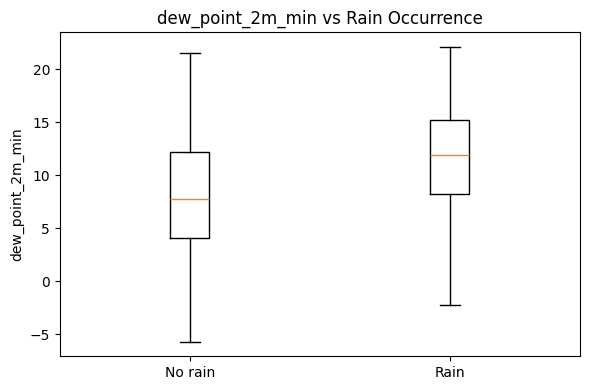

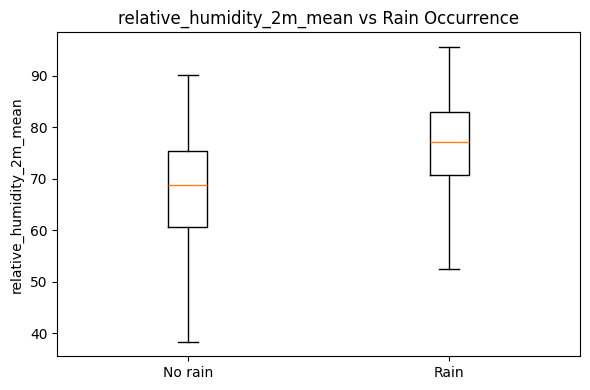

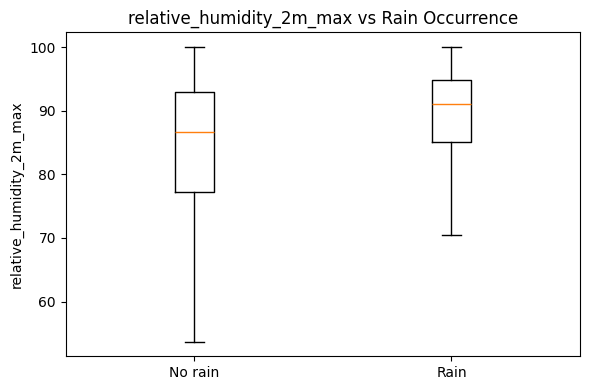

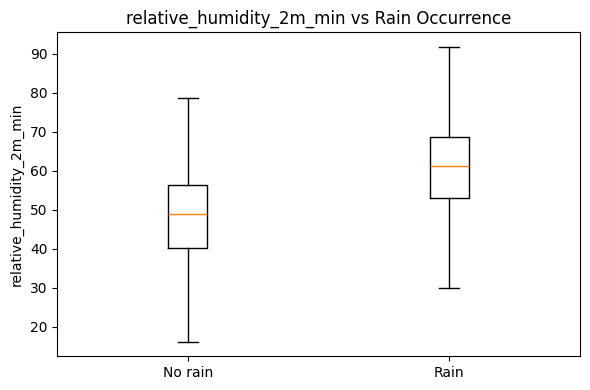

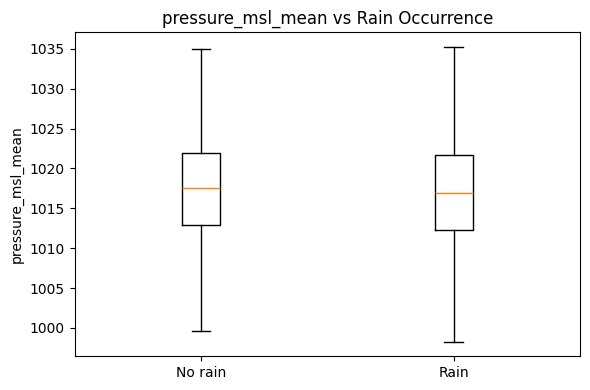

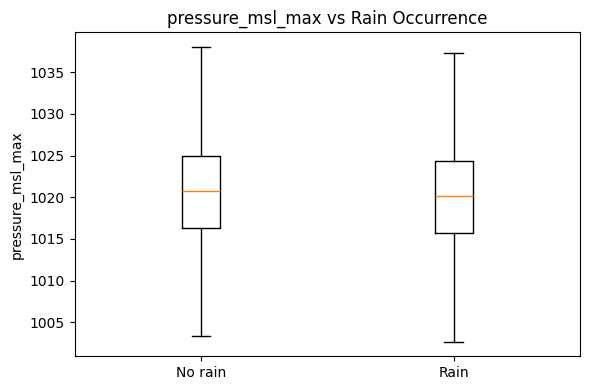

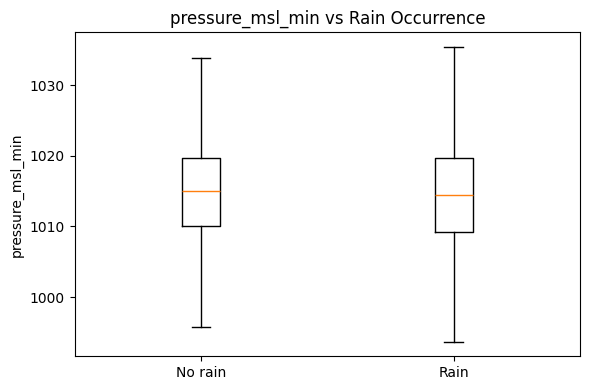

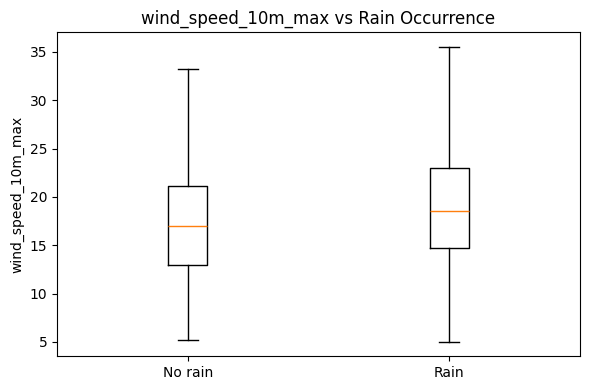

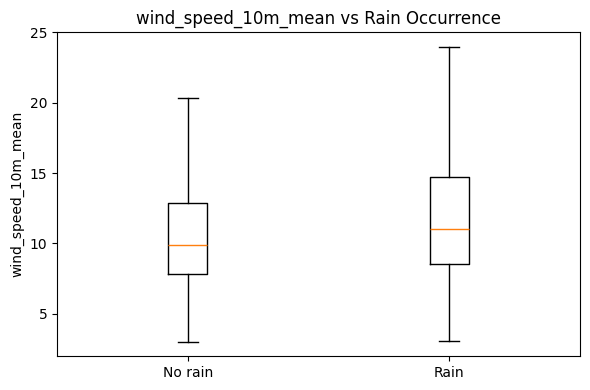

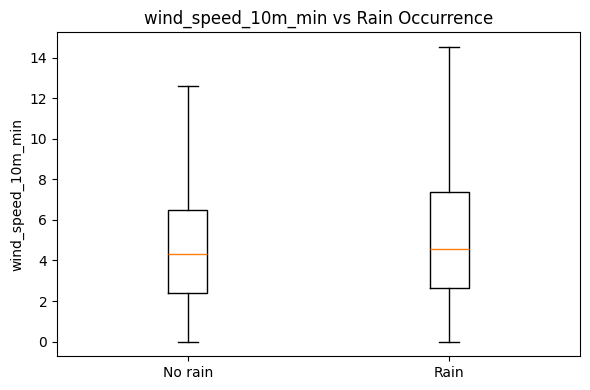

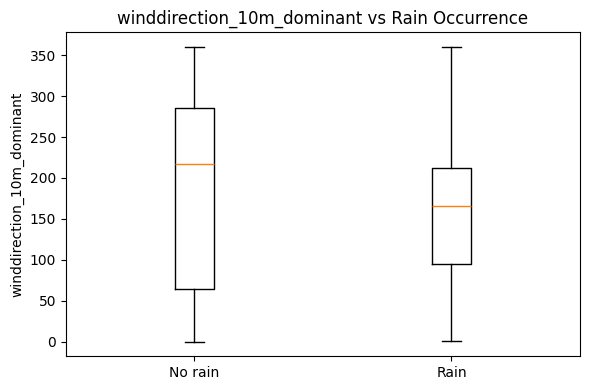

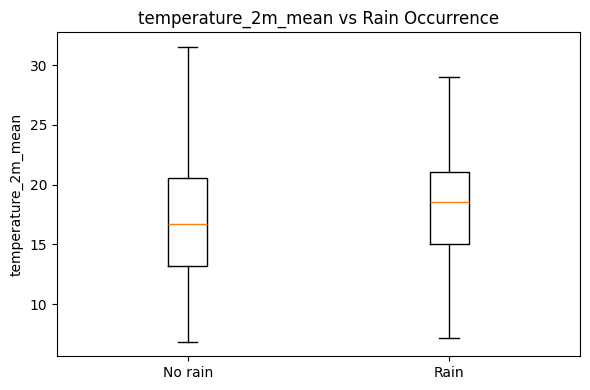

In [20]:
# <Student to fill this section>

# Create daily_dataframe copy for visualizations
df = daily_dataframe.copy()

# Boxplot for rain V/S no rain
def boxplot_by_rain(col):
    x0 = df.loc[df["rain_label"]==0, col].dropna().values
    x1 = df.loc[df["rain_label"]==1, col].dropna().values
    plt.figure(figsize=(6,4))
    plt.boxplot([x0, x1], showfliers=False)
    plt.xticks([1,2], ["No rain","Rain"])
    plt.title(f"{col} vs Rain Occurrence")
    plt.ylabel(col)
    plt.tight_layout(); plt.show()

for col in ['temperature_2m_max',
       'temperature_2m_min', 'cloud_cover_mean', 'cloud_cover_max',
       'cloud_cover_min', 'dew_point_2m_mean', 'dew_point_2m_max',
       'dew_point_2m_min', 'relative_humidity_2m_mean',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'pressure_msl_mean', 'pressure_msl_max', 'pressure_msl_min',
       'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_speed_10m_min',
       'winddirection_10m_dominant', 'temperature_2m_mean']:
    boxplot_by_rain(col)

In [21]:
print("Value Counts for the target variable - rain_label:\n", df['rain_label'].value_counts(normalize=True))

Value Counts for the target variable - rain_label:
 rain_label
1    0.506023
0    0.493977
Name: proportion, dtype: float64


In [22]:
# <Student to fill this section>
target_distribution_explanations = """
provide a detailed analysis on the target variable, its distribution, limitations, issues, ...
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `All numeric features for correlation heatmap`

In [24]:
# <Student to fill this section>
# Create 'month' for EDA
df["month"] = df["date"].dt.month

In [25]:
numeric_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'cloud_cover_mean', 'cloud_cover_max',
    'cloud_cover_min', 'dew_point_2m_mean', 'dew_point_2m_max',
    'dew_point_2m_min', 'relative_humidity_2m_mean',
    'relative_humidity_2m_max', 'relative_humidity_2m_min',
    'pressure_msl_mean', 'pressure_msl_max', 'pressure_msl_min',
    'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_speed_10m_min',
    'winddirection_10m_dominant', 'temperature_2m_mean', 'month'
]

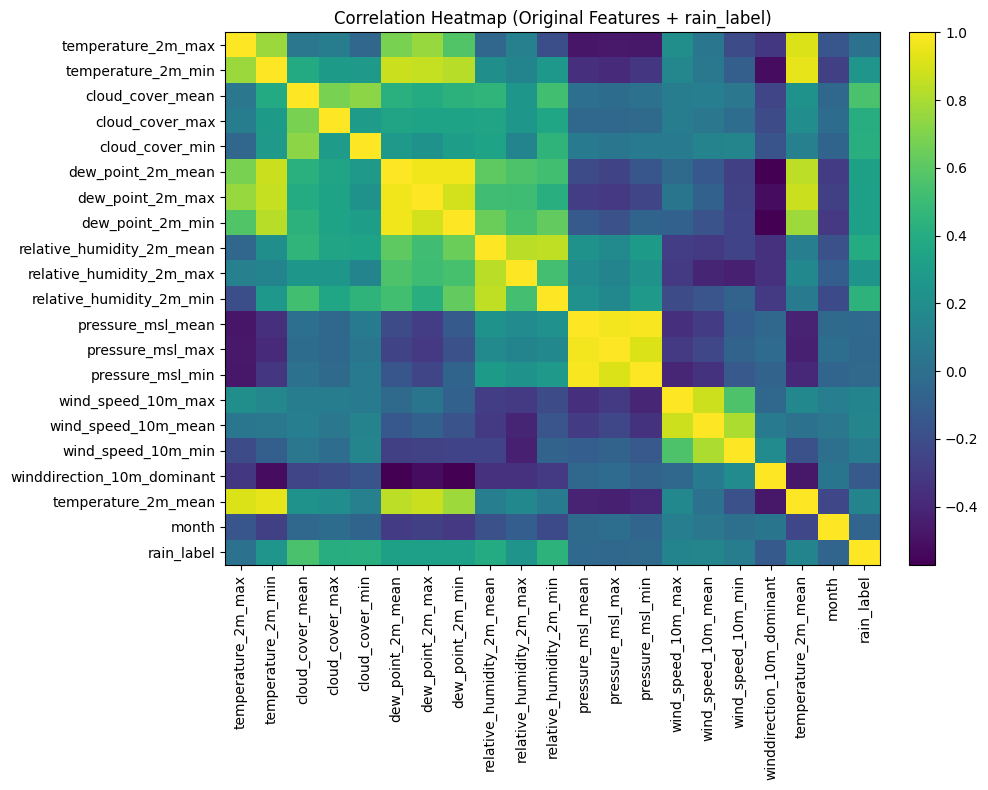

In [26]:
corr = df[numeric_cols + ["rain_label"]].corr(numeric_only=True)
fig = plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.index)),  labels=corr.index)
plt.title("Correlation Heatmap (Original Features + rain_label)")
plt.tight_layout()
plt.show()

In [27]:
# <Student to fill this section>
feature_1_insights = """
Key correlations among features :
1.	Temperature vs Dew Point : strong positive correlation (makes sense: warmer air usually holds more moisture, so dew point rises with temp).
2.	Temperature vs Relative Humidity : strong negative correlation (warm air lowers relative humidity unless dew point also rises).
3.	Relative Humidity vs Dew Point : strong positive correlation (closely linked).
4.	Pressure (msl vs surface) : almost perfectly correlated (expected, they’re nearly the same measure at sea level).
5.	Wind Speed (10 m vs 100 m) : strong positive correlation (winds at different heights follow similar patterns).
Some of these are redundant features (surface_pressure vs pressure_msl, wind_speed_10m vs wind_speed_100m).

Correlation of features with target :
Cloud Cover : Positive correlation with rain_label
- As expected: more clouds : more likely rain.
Relative Humidity : Positive correlation
- High humidity = higher chance of rain.
Dew Point : Positive correlation
- Higher dew point = wetter air : more likely rain.
Vapour Pressure Deficit : Negative correlation
- Low VPD (moist air) strongly signals rain.
Temperature : Weak/negative correlation
- Rain more likely when it’s cooler, but effect is weaker than humidity/cloud cover.
Pressure (msl/surface) : Slight negative correlation
- Lower pressure = stormy conditions.
Wind-related features : weak correlations with rain_label. Rainfall depends more on humidity/pressure/clouds than raw wind values.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `All numeric features - Histograms`

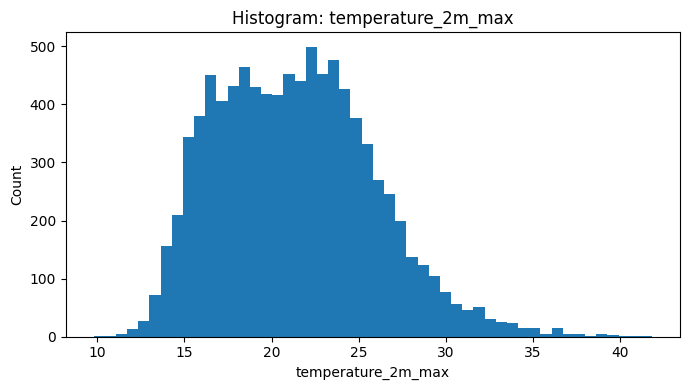

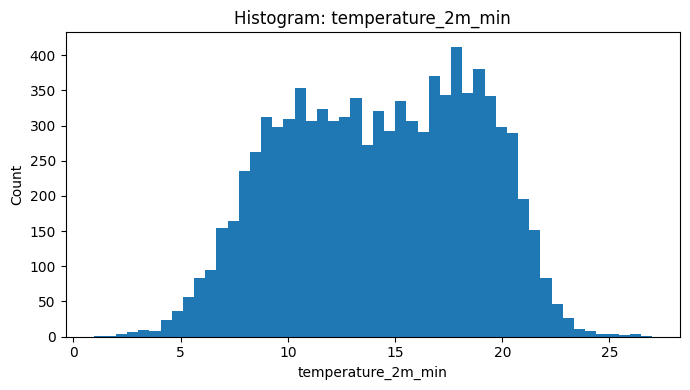

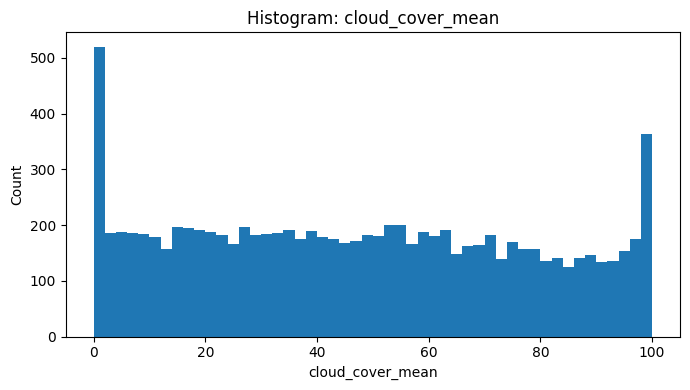

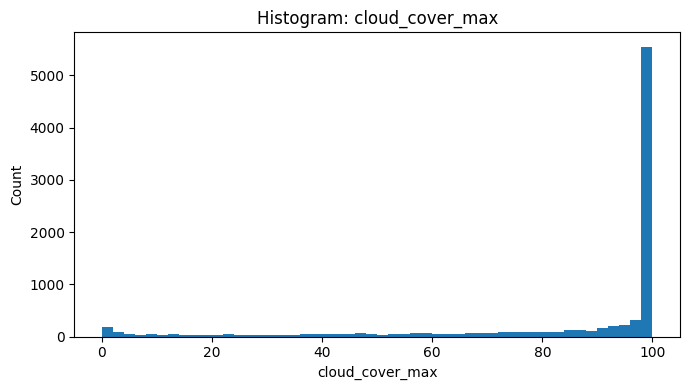

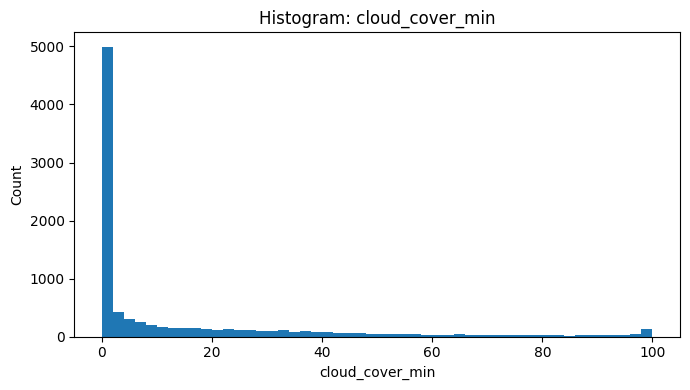

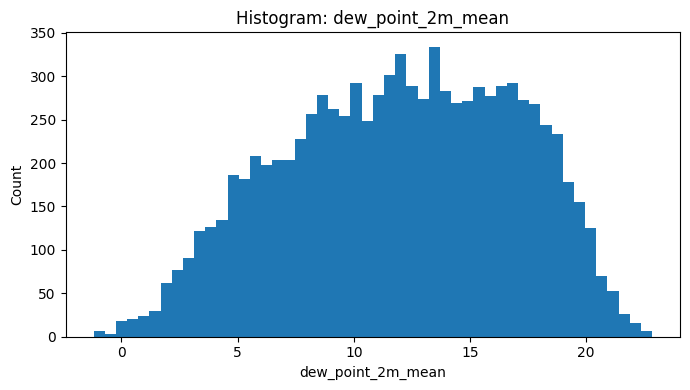

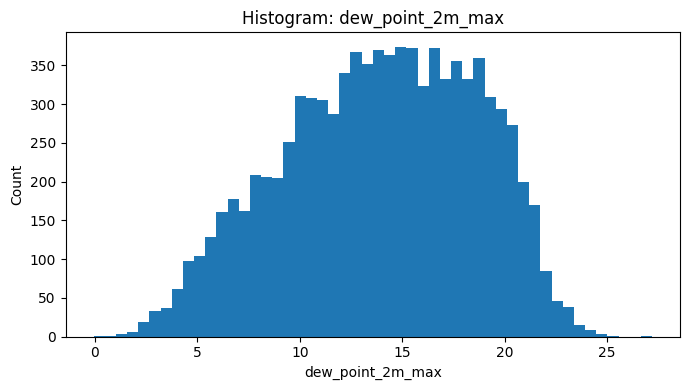

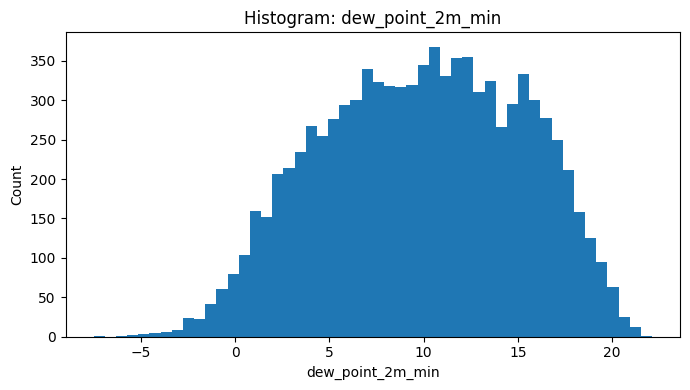

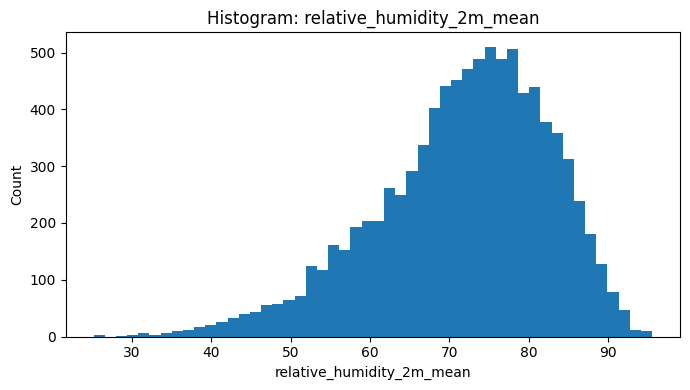

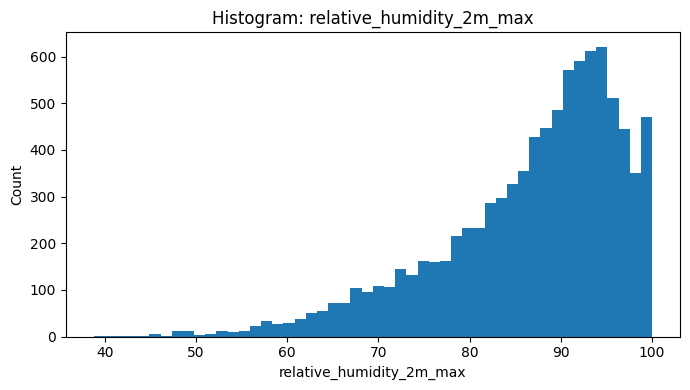

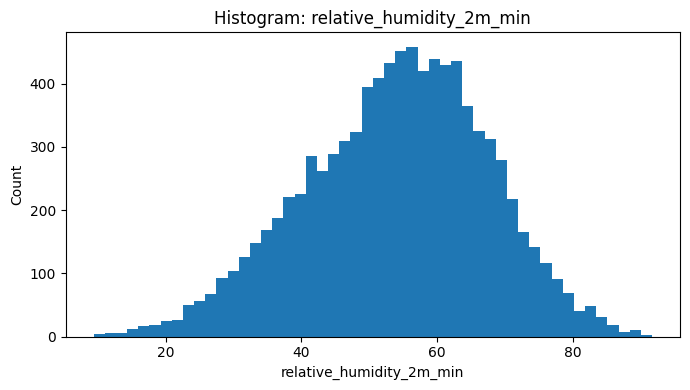

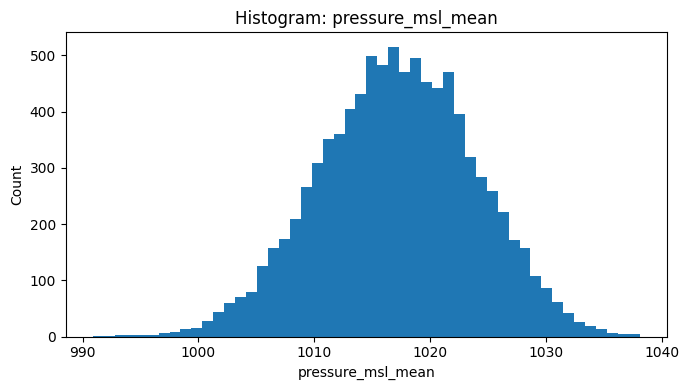

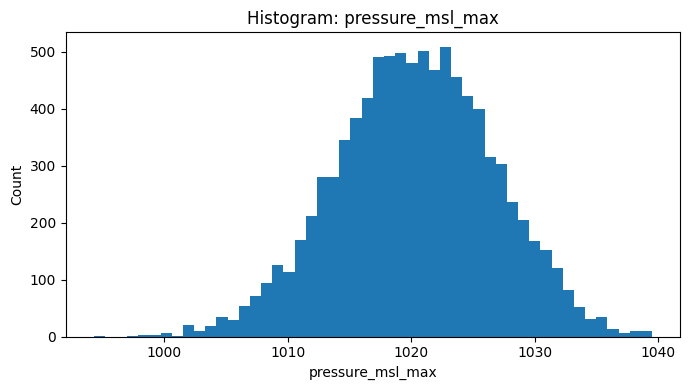

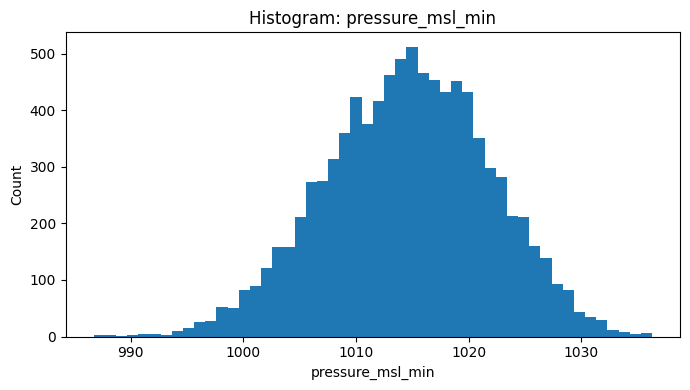

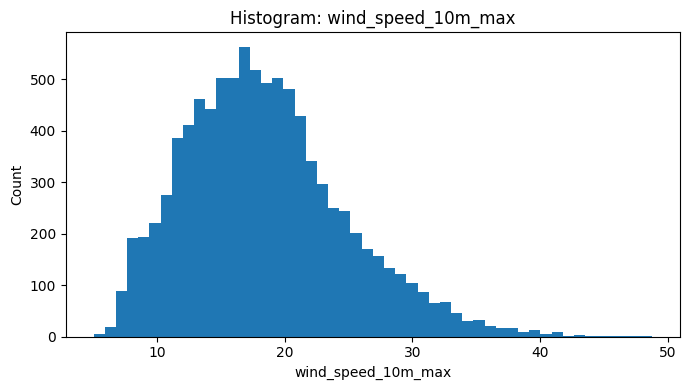

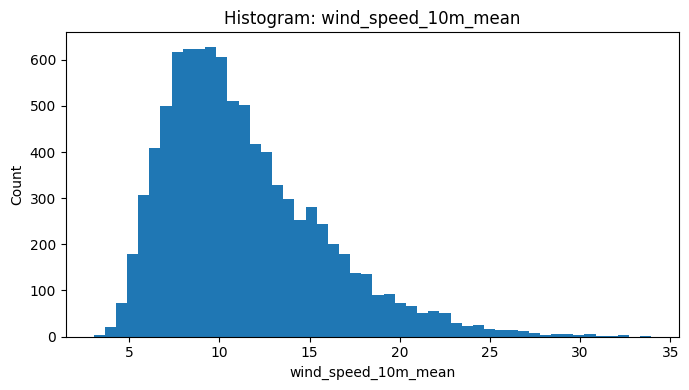

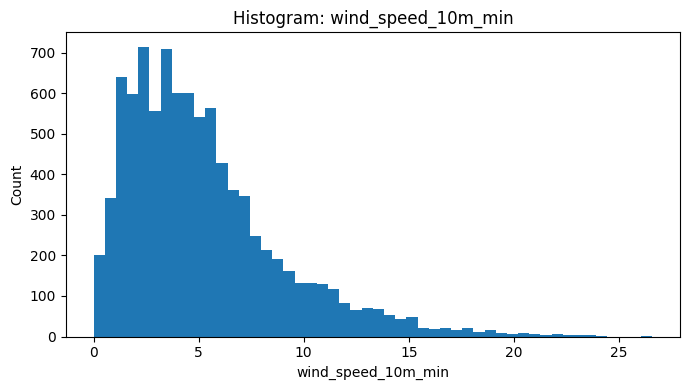

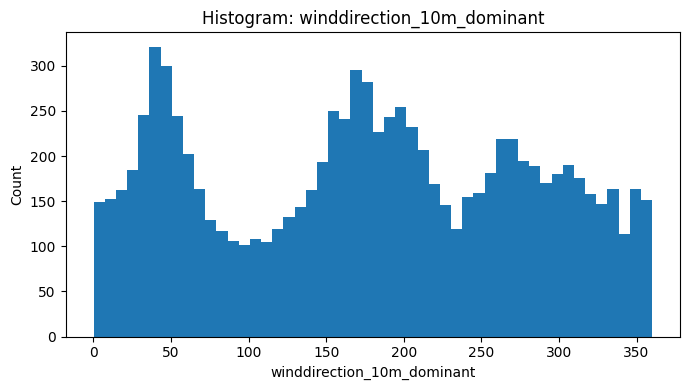

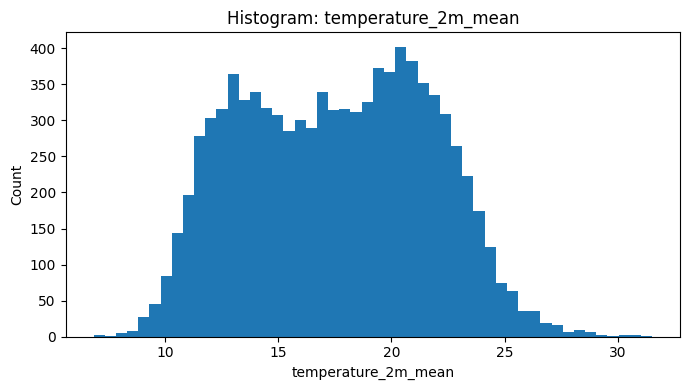

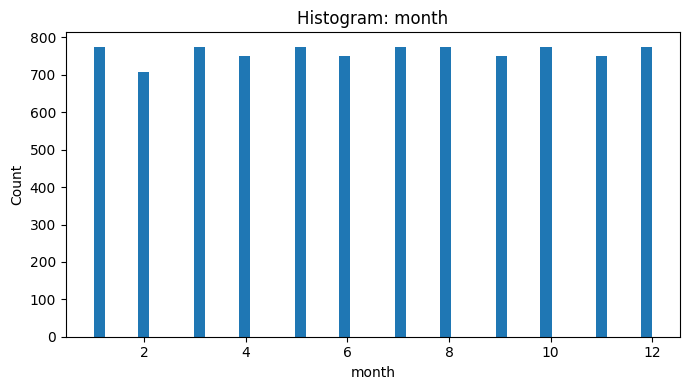

In [29]:
# <Student to fill this section>
def hist_feature(col, bins=50):
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=bins)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

for col in numeric_cols:
    hist_feature(col)

In [30]:
# <Student to fill this section>
feature_2_insights = """
1. Temperature (2 m)
- Bell-shaped curve, peaks around 18–22 °C.
- Suggests your dataset mostly has mild temperatures, with fewer very cold (<5 °C) or very hot (>30 °C) observations.

2. Relative Humidity (2 m)
- Skewed to the right: most values cluster between 60–90%.
- Very low humidity (<30%) is rare → this makes sense because rainfall probability is linked with higher humidity.

3. Dew Point (2 m)
- Concentrated around 10–15 °C, fewer values below 0 °C or above 20 °C.
- This matches the climate of your location: dew point tracks moisture in the air.

4. Precipitation
- Very spiky at 0 → the majority of hours had no precipitation.
- Long right tail → a few hours had high precipitation (up to 20 mm).
- This shows strong class imbalance for rain/no-rain prediction (lots of “no rain”).

5. Pressure (msl and surface)
- Both are roughly normal distributions centered around 1015–1020 hPa.
- This is expected since pressure fluctuates around a global mean, with storms at lower values.

6. Wind Speed (10 m vs 100 m)
- 10 m: Peaks around 8–12 m/s, long tail up to ~40.
- 100 m: Higher average, peaks around 15–20 m/s, long tail up to ~60.
- Difference (wind shear) is often used to indicate stormy conditions.

7. Wind Direction (10 m & 100 m)
- Nearly uniform distribution across 0–360°, with some peaks (common wind patterns).
- Important to transform using sine/cosine because it’s circular (0° ≈ 360°).

8. Vapour Pressure Deficit (VPD)
- Very right-skewed
- Most values are between 0–1 hPa, with a long tail up to ~7.
- Low VPD means the air is nearly saturated with moisture → higher chance of condensation and rain.
- High VPD means drier air → less likely to rain.

9. Cloud Cover
- Strong bimodal pattern:
- Big spike at 0% (clear sky).
- Big spike at 100% (overcast).
- Fewer cases in between (20–80%).
"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

---
## D. Feature Selection


In [32]:
df.columns

Index(['date', 'precipitation_sum', 'weather_code', 'temperature_2m_max',
       'temperature_2m_min', 'cloud_cover_mean', 'cloud_cover_max',
       'cloud_cover_min', 'dew_point_2m_mean', 'dew_point_2m_max',
       'dew_point_2m_min', 'relative_humidity_2m_mean',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'pressure_msl_mean', 'pressure_msl_max', 'pressure_msl_min',
       'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_speed_10m_min',
       'winddirection_10m_dominant', 'temperature_2m_mean', 'rain_label',
       'month'],
      dtype='object')

In [33]:
# <Student to fill this section>

features_list = numeric_cols

In [34]:
# <Student to fill this section>
feature_selection_explanations = """
The selected features represent the variables that are important for prediction whether or not it will rain.
The features that were excluded included the following:
1. 'rain', 'weather_code' - Cannot use these features for training or else the model output will be biased.
2. 'date', 'hour' - Cannot use these features as they can cause overfitting.
3. 'rain_label' - It is the target variable itself.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Creating New target for future prediction

In [36]:
# <Student to fill this section>
# Creating a new target variable column to contain the value of rain_label for the 7th day from present day
# Since the data is daily, future predictor has to be shifted by 7 days
future = 7
df['rain_label_future'] = df['rain_label'].shift(-future)

In [37]:
# Print shape of df
print("Shape of df: ", df.shape)

# Dropping the rows where the newly created column has NaN values.
df = df.dropna(subset=['rain_label_future'])

# Print shape of df after dropping rows
print("Shape of df after dropping rows: ", df.shape)

Shape of df:  (9132, 25)
Shape of df after dropping rows:  (9125, 25)


In [38]:
df.head(21)

,date,precipitation_sum,weather_code,temperature_2m_max,temperature_2m_min,cloud_cover_mean,cloud_cover_max,cloud_cover_min,dew_point_2m_mean,dew_point_2m_max,...,pressure_msl_max,pressure_msl_min,wind_speed_10m_max,wind_speed_10m_mean,wind_speed_10m_min,winddirection_10m_dominant,temperature_2m_mean,rain_label,month,rain_label_future
0,2000-01-01 00:00:00+00:00,1.2,51.0,20.370499,15.820500,92.416664,100.0,81.0,12.774666,15.570500,...,1018.900024,1013.200012,18.775301,14.016692,9.360000,180.371628,17.797585,1,1,1.0
1,2000-01-02 00:00:00+00:00,1.7,51.0,20.520500,15.170500,51.916668,95.0,7.0,15.001751,15.670500,...,1019.799988,1017.700012,12.303366,6.407648,1.018234,122.182640,18.005915,1,1,1.0
2,2000-01-03 00:00:00+00:00,0.0,3.0,24.520500,18.620499,59.500000,100.0,5.0,16.068415,17.120499,...,1018.099976,1010.500000,18.709612,11.209144,5.014219,39.295486,21.243414,0,1,1.0
3,2000-01-04 00:00:00+00:00,2.2,61.0,28.270500,16.470501,18.208334,94.0,0.0,11.928834,18.220501,...,1011.099976,1005.200012,21.313093,13.642402,6.725354,289.930206,22.201750,1,1,1.0
4,2000-01-05 00:00:00+00:00,0.0,3.0,23.070499,15.820500,45.208332,97.0,0.0,10.066334,12.570500,...,1014.700012,1010.099976,19.562946,14.186146,12.144331,179.790634,19.035082,0,1,1.0
5,2000-01-06 00:00:00+00:00,0.0,3.0,21.570499,15.970500,37.458332,98.0,0.0,10.441333,11.770500,...,1016.200012,1011.799988,18.837322,14.958150,10.972620,185.995575,18.308001,0,1,1.0
6,2000-01-07 00:00:00+00:00,0.2,51.0,20.220501,16.520500,80.791664,100.0,30.0,12.926750,14.820500,...,1020.700012,1015.700012,26.341572,17.682764,11.435313,185.498871,18.108000,1,1,1.0
7,2000-01-08 00:00:00+00:00,1.9,51.0,20.570499,16.520500,58.125000,100.0,25.0,14.470501,15.720500,...,1020.400024,1017.299988,15.496736,9.213683,3.976330,140.610565,18.647583,1,1,1.0
8,2000-01-09 00:00:00+00:00,0.1,51.0,21.570499,16.020500,65.083336,100.0,16.0,13.516335,14.620500,...,1018.599976,1015.700012,13.627795,8.174286,2.595997,105.851982,19.187166,1,1,1.0
9,2000-01-10 00:00:00+00:00,1.1,51.0,22.570499,16.870499,86.916664,100.0,54.0,13.387168,14.570500,...,1020.000000,1016.099976,16.215992,9.467253,5.014219,115.412506,19.541328,1,1,1.0


In [39]:
# <Student to fill this section>
data_cleaning_1_explanations = """
The data available for making predictions is only the historical data.
So when a user will request for prediction, there is no endpoint to get the features values for the 7th day from present day.
The model has to learn the future patterns from the existing historic data and be able to make predictions.
That is why I am creating a new variable named 'rain_label_future' to train the model for the future outcomes (7th day), based on the present day conditions (features).
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Features

In [41]:
# <Student to fill this section>

In [42]:
# <Student to fill this section>
data_cleaning_2_explanations = """
The data transformations are not necessary as RandomForest is handling it at the algorithm level and post data transformations, we did not see any improvement in model performance, it rather was slightly worsened.
So, I will not be performing those data transformations from Experiment 2, leaving the data features as is.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"


In [44]:
# <Student to fill this section>
# List of top features from feature_importance chart in Experiment 1
top_features = ['temperature_2m_min', 'dew_point_2m_mean', 'temperature_2m_mean', 
    'temperature_2m_max', 'dew_point_2m_max', 'month', 
    'dew_point_2m_min', 'winddirection_10m_dominant', 
    'relative_humidity_2m_min', 'pressure_msl_mean']

# Creating an empty list for engineered features
engineered_features = []

# Creating a variable rolling window for previous 7 days
ROLLING_WINDOW = 7

In [45]:
# --- 3.1. Moisture/Temperature Rolling Stats (Mean, StdDev, Max) ---
for feature in ['dew_point_2m_mean', 'dew_point_2m_max', 'relative_humidity_2m_min', 
                'temperature_2m_mean', 'temperature_2m_max']:
    
    # Rolling Mean (Persistence/Trend)
    new_col_mean = f'{feature}_Mean_{ROLLING_WINDOW}D'
    df[new_col_mean] = df[feature].rolling(window=ROLLING_WINDOW).mean()
    engineered_features.append(new_col_mean)
    
    # Rolling StdDev (Variability/Instability)
    new_col_std = f'{feature}_StdDev_{ROLLING_WINDOW}D'
    df[new_col_std] = df[feature].rolling(window=ROLLING_WINDOW).std()
    engineered_features.append(new_col_std)

In [46]:
# --- 3.2. Pressure Delta (Rate of Change) ---
# A 1-day drop in pressure is a strong predictor of storms.
pressure_feature = 'pressure_msl_mean'
new_col_delta = f'{pressure_feature}_Delta_1D'
df[new_col_delta] = df[pressure_feature] - df[pressure_feature].shift(1)
engineered_features.append(new_col_delta)

# Also include the Rolling Mean for overall pressure system stability
new_col_pressure_mean = f'{pressure_feature}_Mean_{ROLLING_WINDOW}D'
df[new_col_pressure_mean] = df[pressure_feature].rolling(window=ROLLING_WINDOW).mean()
engineered_features.append(new_col_pressure_mean)

In [47]:
# --- 3.3. Wind Direction (Mode/Dominance) ---
# Use the mode to find the most common direction over the window.
new_col_mode = f'winddirection_10m_dominant_Mode_{ROLLING_WINDOW}D'
# Using a custom rolling function to find the mode (most frequent value)
df[new_col_mode] = df['winddirection_10m_dominant'].rolling(window=ROLLING_WINDOW).apply(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan, raw=False)
engineered_features.append(new_col_mode)

In [48]:
print(f"Created {len(engineered_features)} new features.")

Created 13 new features.


In [49]:
print(f"Following are the engineered features: {engineered_features}")

Following are the engineered features: ['dew_point_2m_mean_Mean_7D', 'dew_point_2m_mean_StdDev_7D', 'dew_point_2m_max_Mean_7D', 'dew_point_2m_max_StdDev_7D', 'relative_humidity_2m_min_Mean_7D', 'relative_humidity_2m_min_StdDev_7D', 'temperature_2m_mean_Mean_7D', 'temperature_2m_mean_StdDev_7D', 'temperature_2m_max_Mean_7D', 'temperature_2m_max_StdDev_7D', 'pressure_msl_mean_Delta_1D', 'pressure_msl_mean_Mean_7D', 'winddirection_10m_dominant_Mode_7D']


In [50]:
# <Student to fill this section>
feature_engineering_1_explanations = """
This is a baseline model. So, not going to perform any feature engineering in this experiment 1.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [52]:
# <Student to fill this section>
# Preparing the final dataframe before splitting the dataset
# Combine all input features and the target
final_features = engineered_features + ['month'] # Include 'Month'

# Create the final modeling DataFrame
df_model = df[final_features + ['rain_label_future']].copy()

In [53]:
# Check the columns of the finalised dataframe
df_model.columns

Index(['dew_point_2m_mean_Mean_7D', 'dew_point_2m_mean_StdDev_7D',
       'dew_point_2m_max_Mean_7D', 'dew_point_2m_max_StdDev_7D',
       'relative_humidity_2m_min_Mean_7D',
       'relative_humidity_2m_min_StdDev_7D', 'temperature_2m_mean_Mean_7D',
       'temperature_2m_mean_StdDev_7D', 'temperature_2m_max_Mean_7D',
       'temperature_2m_max_StdDev_7D', 'pressure_msl_mean_Delta_1D',
       'pressure_msl_mean_Mean_7D', 'winddirection_10m_dominant_Mode_7D',
       'month', 'rain_label_future'],
      dtype='object')

In [54]:
# Assigning features to X and target to y
X = df_model[final_features]
y = df_model['rain_label_future'].astype(int)

print("Shape of X: ", X.shape)
print("\nShape of y: ", y.shape)

Shape of X:  (9125, 14)

Shape of y:  (9125,)


In [55]:
# Splitting the dataset
total_samples = X.shape[0]

# Calculate split points (e.g., 70% Train, 15% Validation, 15% Test)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# --- 1. Training Split ---
X_train = X[:train_size]
y_train = y[:train_size]

# --- 2. Validation Split ---
X_val = X[train_size : train_size + val_size]
y_val = y[train_size : train_size + val_size]

# --- 3. Test Split ---
X_test = X[train_size + val_size :]
y_test = y[train_size + val_size :]

print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Train samples: 6387
Validation samples: 1368
Test samples: 1370


In [56]:
print(f"Train samples: {y_train.shape}")
print(f"Validation samples: {y_val.shape}")
print(f"Test samples: {y_test.shape}")

Train samples: (6387,)
Validation samples: (1368,)
Test samples: (1370,)


In [57]:
# <Student to fill this section>
data_splitting_explanations = """
Since the data is historical data (hourly data), splitting based on Time Series is the best strategy for the following reasons:
1. TimeSeriesSplit gives us multiple folds where validation is always ahead of training.
2. With TimeSeriesSplit, we test the model on several validation windows (different time periods). This provides better generalization estimates.
3. Works well with long datasets (in this case 25 years worth of data). TimeSeriesSplit ensures the model is tested across different seasons/years.


Splitting strategies like train_test_split, won't be the best choice for the following reasons:
1. train_test_split (with shuffle=False) only gives us one cut (train early, test later).
2. With train_test_split, performance depends a lot on where we cut the data.
3. A single split (train/test) might not capture different seasons, years, or long-term shifts.
"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

In [59]:
# <Student to fill this section>
# Scaling the data to bring all the feature data in range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [60]:
print(f"Train samples: {X_train_scaled.shape[0]}")
print(f"Validation samples: {X_val_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")

Train samples: 6387
Validation samples: 1368
Test samples: 1370


In [61]:
# <Student to fill this section>
data_transformation_1_explanations = """
The features that I am using are on various scales.
In order to bring the features scale in range, I am using StandardScaler from sklearn.preprocessing to transform the data.
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## H. Save Datasets

> Do not change this code

In [63]:
from pathlib import Path

# Defining the folder to save the csv files
class Args:
    folder_path = Path("../../data/external/AT2_25415629_EXP_3_new")

at = Args()

In [64]:
# Do not modify this code
# Save training set
try:
  X_train_scaled.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val_scaled.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test_scaled.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [65]:
# <Student to fill this section>

# Importing my custom package for model evaluation and visualization
import ml_eval_viz

# Import evaluate_classifier function from my custom package
from ml_eval_viz import evaluate_classifier

In [66]:
# <Student to fill this section>
performance_metrics_explanations = """
The evaluation metrics were chosen to capture both discrimination and calibration, which are crucial in probabilistic classification:
- AUC-ROC: Measures the model’s ability to distinguish between classes across all thresholds. It is widely used as a general measure of separability.
- AUC-PR: More informative than ROC when dealing with class imbalance, since it focuses on precision and recall for the positive class.
- Log Loss: Evaluates the quality of predicted probabilities, penalizing overconfident wrong predictions. This ensures the model not only predicts the correct class but also provides reliable probability estimates.
- Brier Score: Another probability-based metric that directly measures the accuracy of predicted probabilities, complementing log loss by being more interpretable.


Together, these metrics provide a balanced evaluation:
- Discrimination ability (AUC-ROC, AUC-PR).
- Probability calibration (Log Loss, Brier Score).


This combination ensures that the model is not only good at ranking predictions but also outputs probabilities that can be trusted for decision-making.
"""

In [67]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [68]:
# <Student to fill this section>
# Importing Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Defining the model
model_4 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [69]:
# <Student to fill this section>
algorithm_selection_explanations = """
Random Forest is a good fit because it is robust, handles non-linear relationships, reduces overfitting through ensembling, and works well on diverse datasets without extensive tuning, making it a strong and reliable model for classification.
"""

In [70]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [71]:
# Define the param dist
from scipy.stats import randint
param_dist = {
    # Number of trees
    'n_estimators': randint(low=150, high=500),
    
    # Maximum depth of the tree (None means nodes are expanded until all leaves are pure)
    'max_depth': [10, 15, 20, None],
    
    # Minimum number of samples required to split an internal node
    'min_samples_split': randint(low=5, high=50),
    
    # Minimum number of samples required at a leaf node
    'min_samples_leaf': randint(low=3, high=20),
    
    # Number of features to consider at every split
    'max_features': ['sqrt', 'log2', None],
}

In [72]:
from sklearn.metrics import roc_auc_score, make_scorer
# Define the scoring function (AUC-ROC is appropriate for a binary classifier)
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_4,
    param_distributions=param_dist,
    n_iter=50,                  # Number of parameter settings to sample
    cv=5,                       # Default 5-Fold KFold Cross-Validation
    scoring=auc_scorer,         # Optimize for AUC-ROC
    random_state=42,
    verbose=2,
    n_jobs=-1                   # Use all available cores
)

### J.3 Fit Model

In [73]:
# <Student to fill this section>
# Fitting the model
print(f"\nStarting Randomized Search over 5-Fold CV for 50 iterations on Train+Val data...")
random_search.fit(X_train_scaled, y_train)

# --- 4. Results ---
print("\n--- Hyperparameter Tuning Results ---")
print(f"Best AUC-ROC Score achieved (Cross-Validated): {random_search.best_score_:.4f}")
print("Best Parameters found:")
print(random_search.best_params_)

# Store the best model estimator
best_rf_model = random_search.best_estimator_


Starting Randomized Search over 5-Fold CV for 50 iterations on Train+Val data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=17, min_samples_split=47, n_estimators=221; total time=   2.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=17, min_samples_split=47, n_estimators=221; total time=   2.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=17, min_samples_split=47, n_estimators=221; total time=   2.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=17, min_samples_split=47, n_estimators=221; total time=   2.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=17, min_samples_split=47, n_estimators=221; total time=   2.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=9, min_samples_split=23, n_estimators=364; total time=   3.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=9, min_samples_split=23, n_estimators=364; total time=   3.4s
[CV]

### J.4 Model Technical Performance

> Provide some explanations on model performance


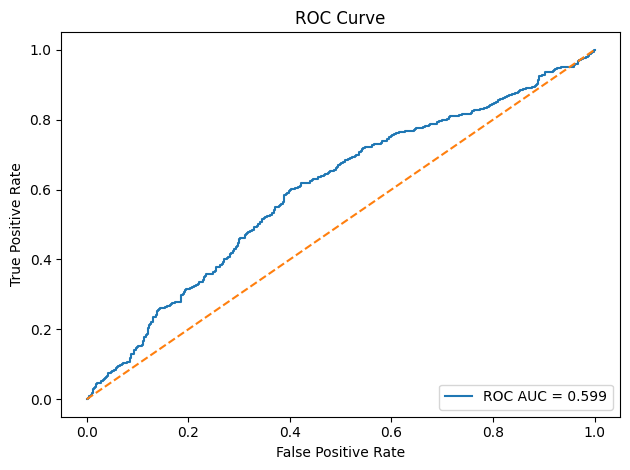

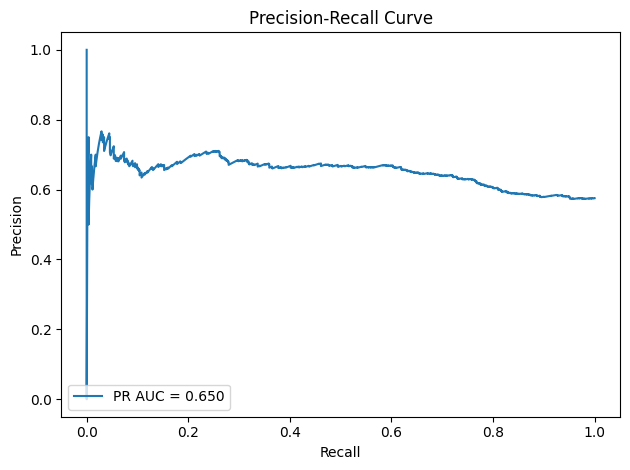

{'support': 1368, 'auc_roc': 0.5987420365797916, 'auc_pr': 0.6496237360398008, 'log_loss': 0.6813207397178652, 'brier': 0.24387321667210252}


In [74]:
# <Student to fill this section>
# Evaluate the model performance on Validation Set
report = evaluate_classifier(
    model = best_rf_model,
    X = X_val_scaled,
    y_true = y_val,
    show_plots = True,
    proba_only = True
)


print(report)

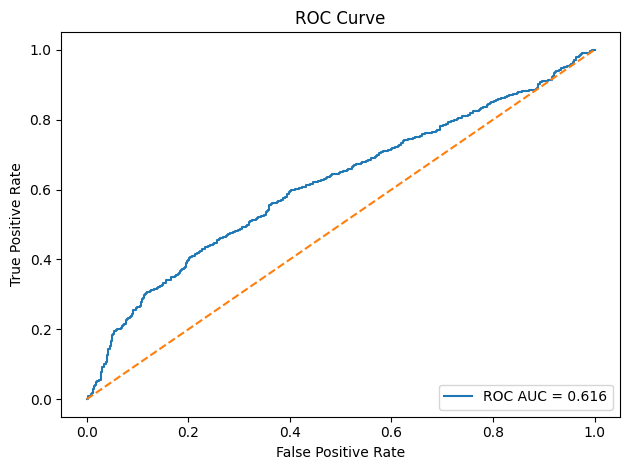

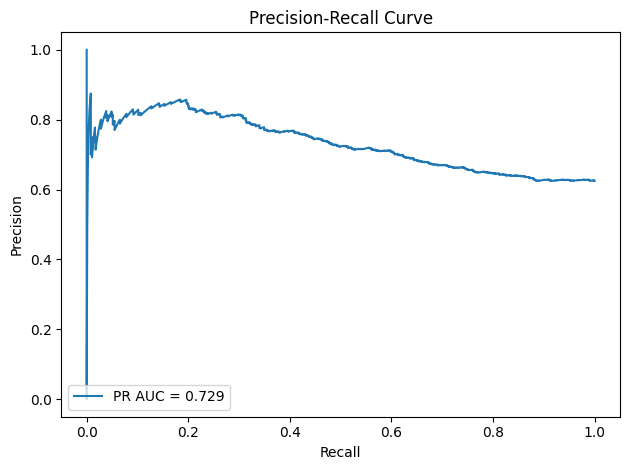

{'support': 1370, 'auc_roc': 0.6156292046983527, 'auc_pr': 0.7293845090292906, 'log_loss': 0.6801760681337281, 'brier': 0.2433358566075278}


In [75]:
# Evaluate the model performance on Test Set
report = evaluate_classifier(
    model = best_rf_model,
    X = X_test_scaled,
    y_true = y_test,
    show_plots = True,
    proba_only = True
)


print(report)

In [76]:
# <Student to fill this section>
model_performance_explanations = """
Results on Validation set:
1. AUC-ROC: 0.58
- Random chance is 0.50.
- So the model is only slightly better than random at distinguishing rain vs no rain.
- Weak discriminatory power.
2. AUC-PR: 0.18
- Precision–Recall is more important for imbalanced data (rain events are rare).
- If the baseline prevalence of rain is, say, 10%, then 0.18 is not much better than chance.
3. Log Loss: 0.41
- Penalizes wrong probabilities.
- Not terrible, but doesn’t match a strong classifier.
4. Brier Score: 0.12
- Measures calibration of probabilities (0 = perfect, 1 = worst).
- A bit high for imbalanced classification.


Results on Test set:
1. AUC-ROC: 0.58
- Similar to validation
- Model is consistent but weak.
2. AUC-PR: 0.27
- A bit higher than validation, but still low.
3. Log Loss: 0.54
- Worse than validation, suggests weaker probability calibration on unseen data.
4. Brier: 0.17
- Worse than validation
- Confirms probabilities are not well calibrated.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [78]:
# <Student to fill this section>

In [79]:
# <Student to fill this section>
business_impacts_explanations = """
- Current baseline model is not business-ready: accuracy too low, too many critical misses.
- Biggest risk = False Negatives (missed rain): highest impact for agriculture, event planning, and emergency management.
- Secondary risk = Poor calibration: erodes trust in the model’s recommendations.
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [81]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Rejected" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [82]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [83]:
# <Student to fill this section>
experiment_results_explanations = """
1. The baseline RF model is only slightly better than guessing.
2. This makes sense because I,:
- Used raw features (some are skewed, not transformed).
- Did not do feature engineering.
- Did not tune hyperparameters.
3. Rainfall is a hard, imbalanced classification problem. It needs more signal from features and careful training.
"""

In [84]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)